# Smart Lender — Applicant Creditworthiness Prediction

End-to-end machine learning notebook that predicts whether a loan applicant will be **Approved** or **Rejected**.

**Pipeline**
1. Data collection & inspection
2. Exploratory Data Analysis (univariate / bivariate / multivariate)
3. Preprocessing (imputation, encoding, scaling)
4. SMOTE balancing + stratified split
5. Model building: Decision Tree, Random Forest, KNN, XGBoost
6. Evaluation & comparison
7. Save best model + scaler

## Epic 1 — Data Collection

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'Flask'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

import preprocessing as pp

df = pd.read_csv(os.path.join('..', 'Dataset', 'loan_prediction.csv'))
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print('Shape          :', df.shape)
print('\nData types:'); print(df.dtypes)
print('\nStatistical summary:'); display(df.describe(include='all').T)
print('\nMissing values:'); print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nLoan_Status distribution:'); print(df['Loan_Status'].value_counts())

Shape          : (614, 13)

Data types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0



Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicates: 0

Loan_Status distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


**Insight:** 614 rows, 13 columns. Target is imbalanced (Y=422 / N=192, ~69/31). Missing values exist in Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term and Credit_History.

## Epic 2 — Exploratory Data Analysis
### 2.1 Univariate Analysis

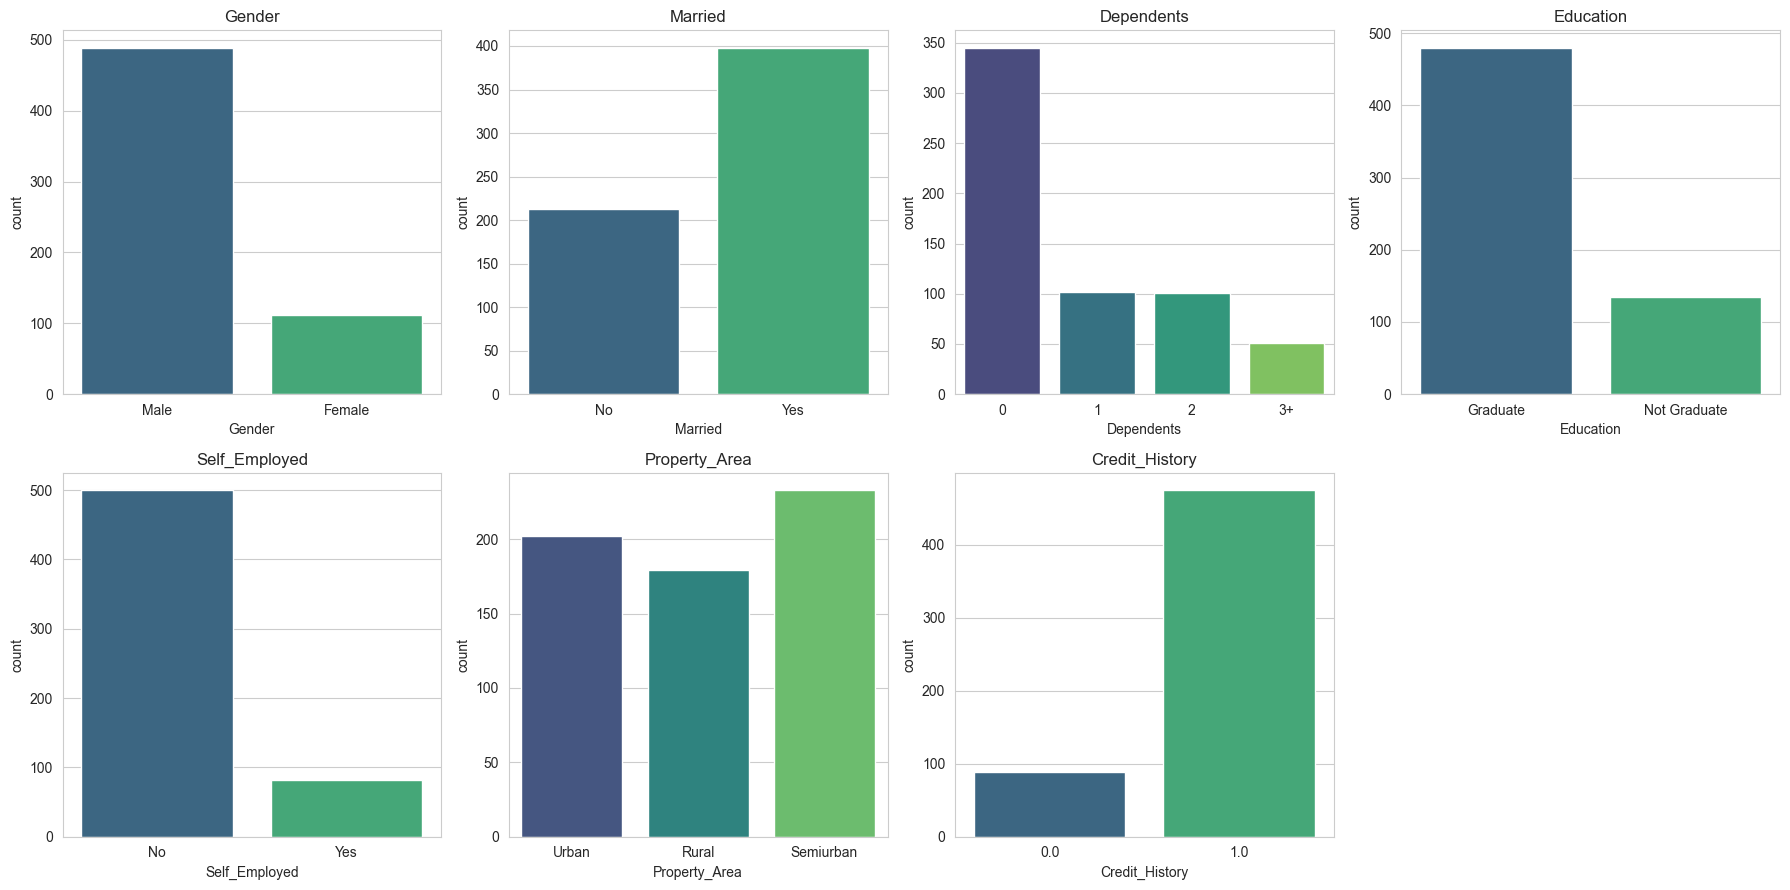

In [3]:
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Credit_History']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, x=col, ax=ax, palette='viridis', hue=col, legend=False)
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

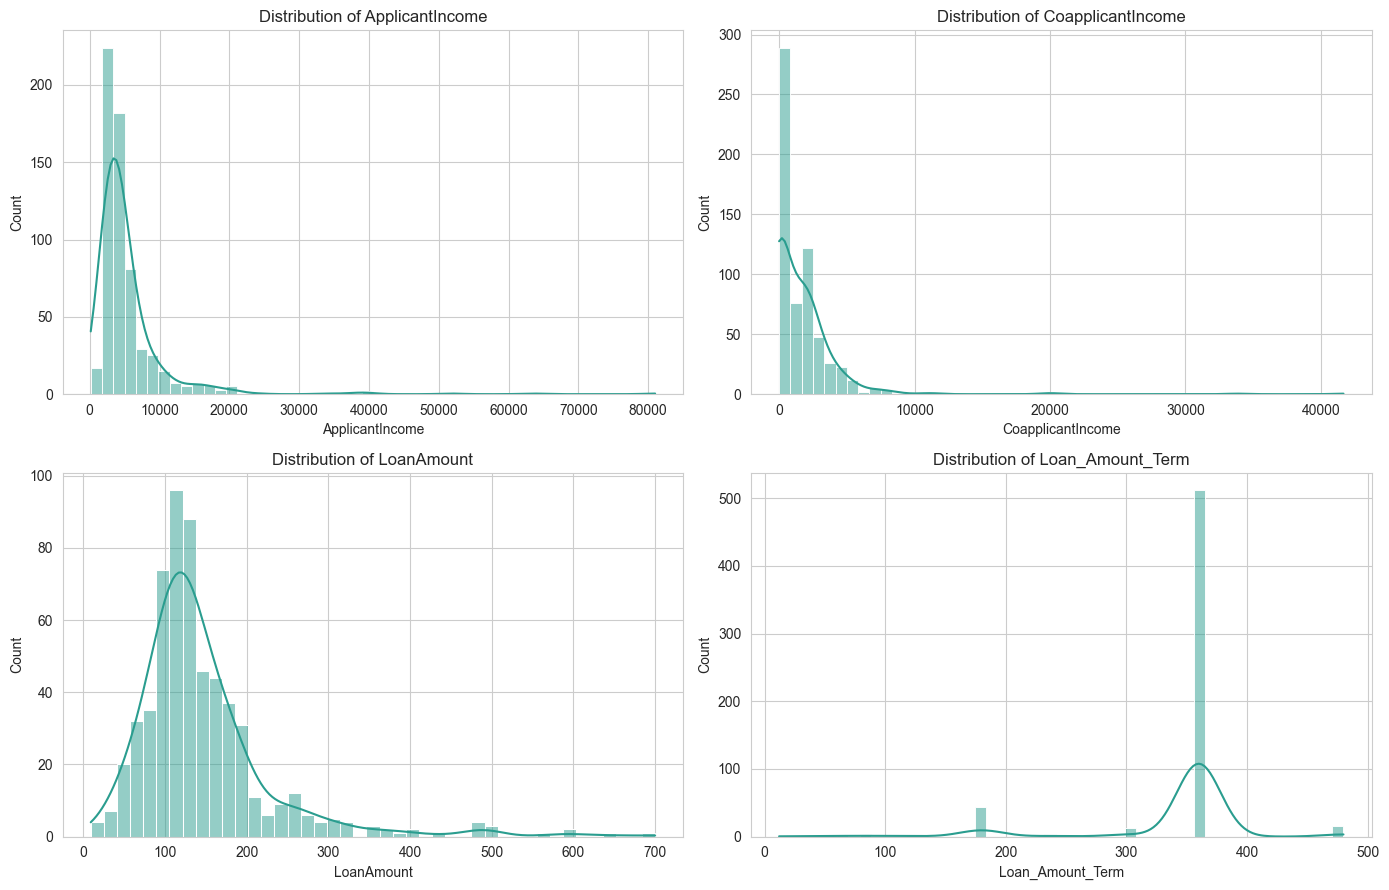

In [4]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout(); plt.show()

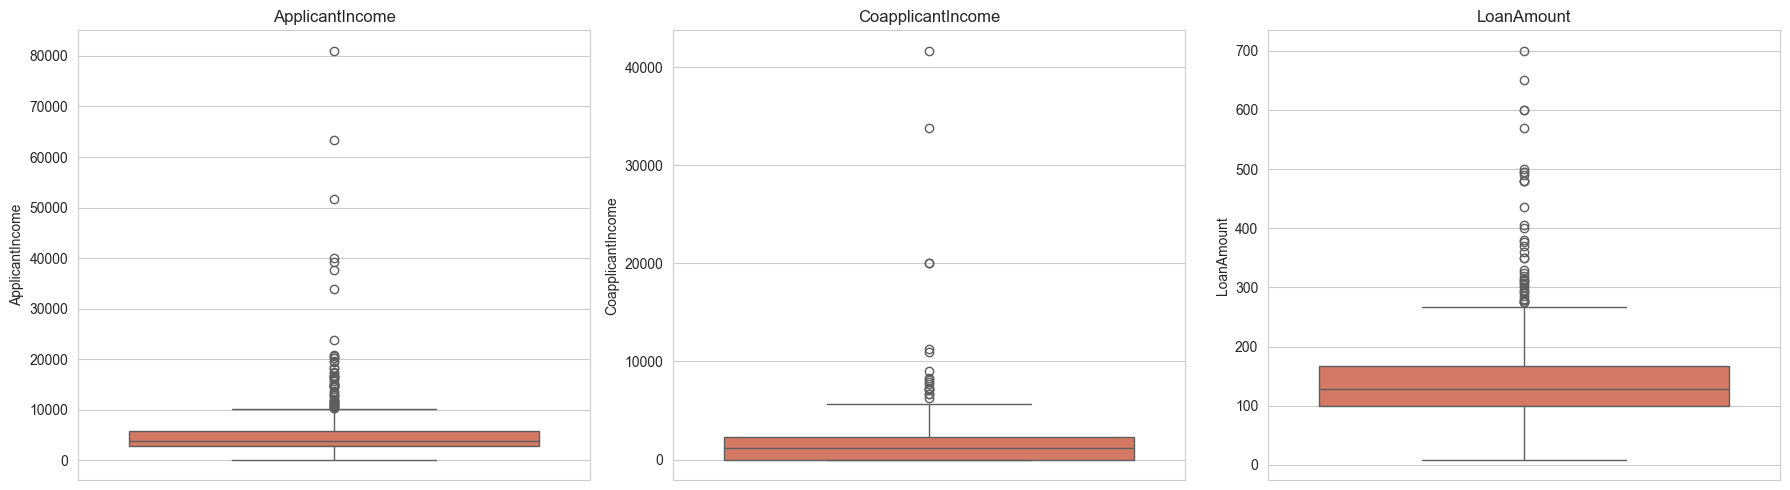

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['ApplicantIncome','CoapplicantIncome','LoanAmount']):
    sns.boxplot(y=df[col], ax=ax, color='#e76f51')
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Insight:** ApplicantIncome and CoapplicantIncome are heavily right-skewed with outliers; LoanAmount is also right-skewed. Most applicants are male, married, graduates, not self-employed, with a credit history of 1.0.

### 2.2 Bivariate Analysis — Loan_Status vs categorical features

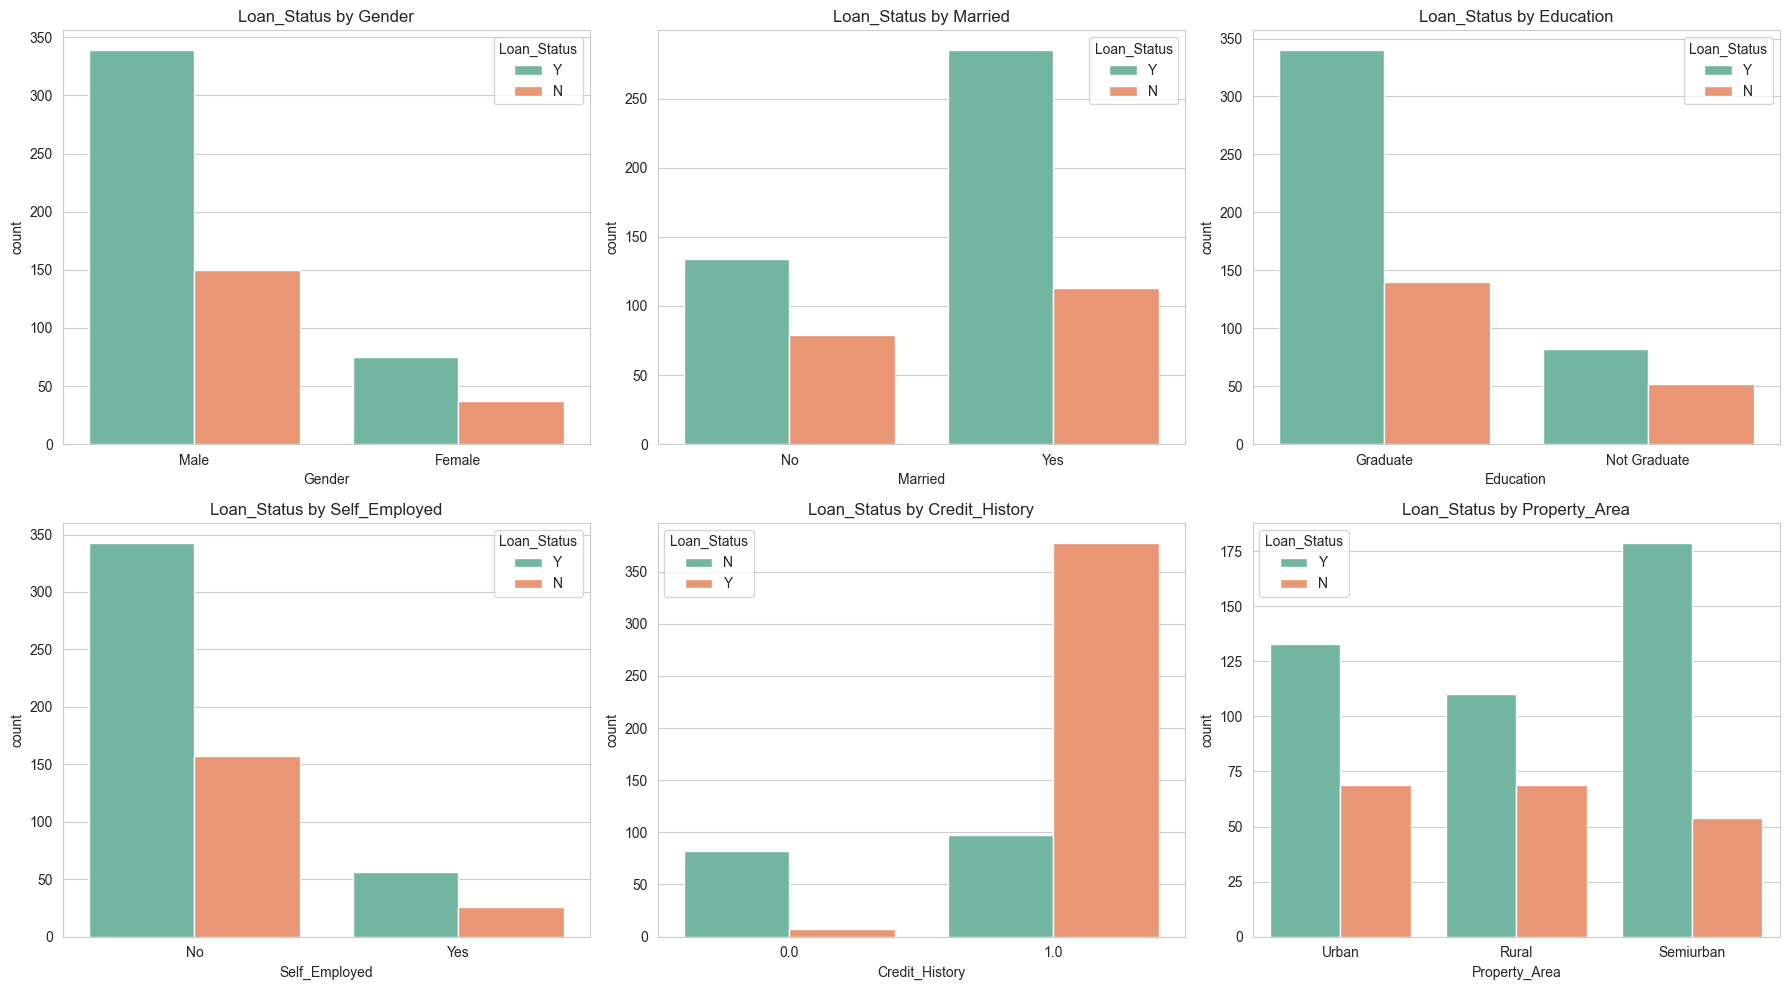

In [6]:
bi_cols = ['Gender','Married','Education','Self_Employed','Credit_History','Property_Area']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), bi_cols):
    sns.countplot(data=df, x=col, hue='Loan_Status', ax=ax, palette='Set2')
    ax.set_title(f'Loan_Status by {col}')
plt.tight_layout(); plt.show()

In [7]:
for col in bi_cols:
    print(f'\n--- {col} ---')
    print(pd.crosstab(df[col], df['Loan_Status'], normalize='index').round(3))


--- Gender ---
Loan_Status      N      Y
Gender                   
Female       0.330  0.670
Male         0.307  0.693

--- Married ---
Loan_Status      N      Y
Married                  
No           0.371  0.629
Yes          0.284  0.716

--- Education ---
Loan_Status       N      Y
Education                 
Graduate      0.292  0.708
Not Graduate  0.388  0.612

--- Self_Employed ---
Loan_Status        N      Y
Self_Employed              
No             0.314  0.686
Yes            0.317  0.683

--- Credit_History ---
Loan_Status         N      Y
Credit_History              
0.0             0.921  0.079
1.0             0.204  0.796

--- Property_Area ---
Loan_Status        N      Y
Property_Area              
Rural          0.385  0.615
Semiurban      0.232  0.768
Urban          0.342  0.658


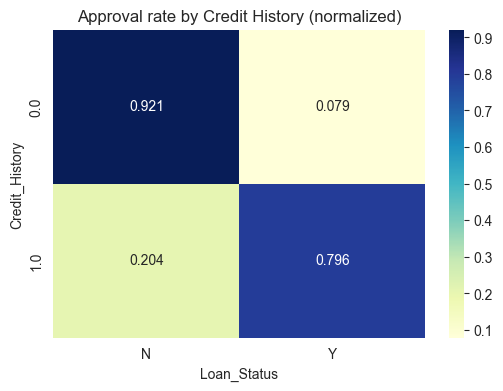

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index'),
            annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('Approval rate by Credit History (normalized)')
plt.show()

**Insight:** Credit history is by far the strongest predictor — applicants with history=1.0 are approved ~80% of the time vs ~8% for history=0.0. Married and semiurban/urban property areas also correlate positively with approval.

### 2.3 Multivariate Analysis

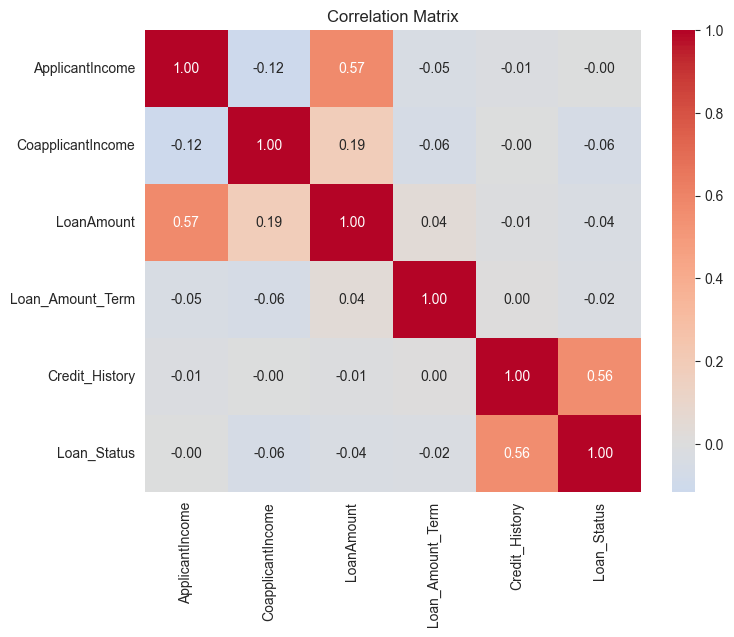

In [9]:
num_df = df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']].copy()
num_df['Loan_Status'] = df['Loan_Status'].map({'Y':1,'N':0})
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

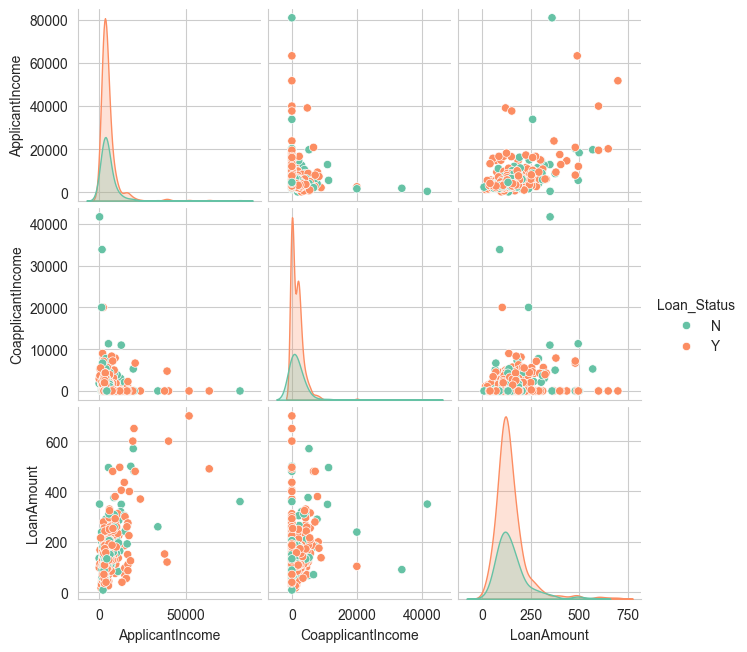

In [10]:
sns.pairplot(df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Status']].dropna(),
             hue='Loan_Status', palette='Set2', height=2.2)
plt.show()

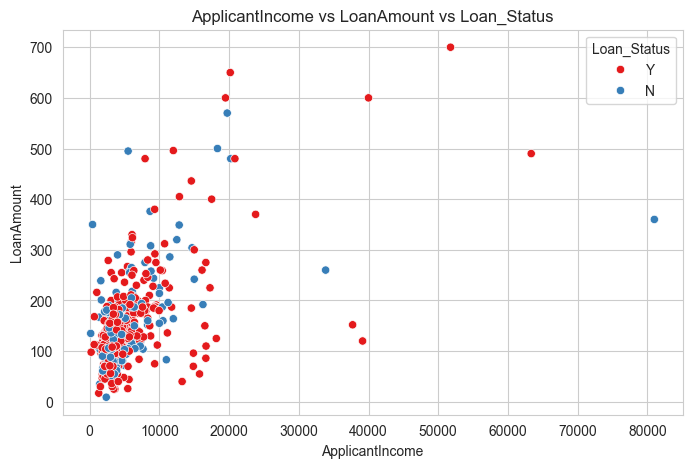

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', palette='Set1')
plt.title('ApplicantIncome vs LoanAmount vs Loan_Status')
plt.show()

**Insight:** LoanAmount correlates positively with ApplicantIncome. Approval is broadly spread, but high-income / moderate-loan applicants skew toward approval.

## Epic 3 — Data Preprocessing

In [12]:
data = df.drop(columns=['Loan_ID'], errors='ignore').drop_duplicates().reset_index(drop=True)
y = pp.encode_target(data['Loan_Status'])
X = pp.encode_features(data.drop(columns=['Loan_Status']))
print('Feature matrix:', X.shape)
X.head()

Feature matrix: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,1.0,0.0,5849.0,0.0,128.0,360.0,1.0,0.0,1.0
1,1.0,1.0,1.0,1.0,0.0,4583.0,1508.0,128.0,360.0,1.0,0.0,0.0
2,1.0,1.0,0.0,1.0,1.0,3000.0,0.0,66.0,360.0,1.0,0.0,1.0
3,1.0,1.0,0.0,0.0,0.0,2583.0,2358.0,120.0,360.0,1.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,6000.0,0.0,141.0,360.0,1.0,0.0,1.0


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X[pp.NUMERIC_COLS] = scaler.fit_transform(X[pp.NUMERIC_COLS])

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42, stratify=y.values)

X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (674, 12)  Test: (123, 12)


## Epic 4 — Model Building

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

models = {
    'DecisionTree': DecisionTreeClassifier(max_depth=6, min_samples_split=20,
                                           min_samples_leaf=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10,
                                           min_samples_split=10, min_samples_leaf=4,
                                           max_features='sqrt', random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=9, weights='distance', metric='manhattan'),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9, gamma=2,
                             reg_alpha=0.3, reg_lambda=1.5, min_child_weight=3,
                             eval_metric='logloss', tree_method='hist',
                             random_state=42, n_jobs=-1),
}

rows = []
fitted = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    fitted[name] = m
    ptr, pte = m.predict(X_train), m.predict(X_test)
    rows.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, ptr),
        'Test Accuracy':  accuracy_score(y_test, pte),
        'Precision': precision_score(y_test, pte, zero_division=0),
        'Recall':    recall_score(y_test, pte, zero_division=0),
        'F1 Score':  f1_score(y_test, pte, zero_division=0),
    })
results = pd.DataFrame(rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)
results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.859050,0.813008,0.836957,0.905882,0.870056
1,RandomForest,0.921365,0.804878,0.835165,0.894118,0.863636
2,KNN,1.000000,0.756098,0.816092,0.835294,0.825581
3,DecisionTree,0.817507,0.715447,0.837838,0.729412,0.779874


Best model: XGBoost


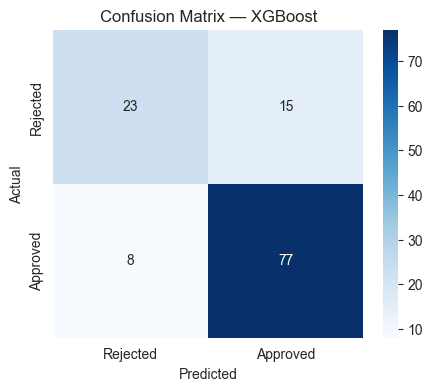

In [15]:
best_name = results.loc[0, 'Model']
best = fitted[best_name]
print('Best model:', best_name)

pred = best.predict(X_test)
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

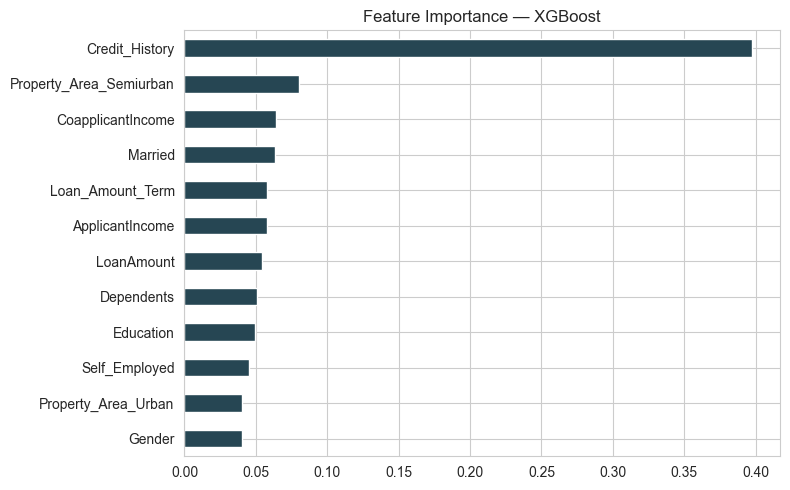

In [16]:
# Feature importance (tree-based models)
if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=pp.FEATURES).sort_values()
    imp.plot(kind='barh', figsize=(8,5), color='#264653')
    plt.title(f'Feature Importance — {best_name}')
    plt.tight_layout(); plt.show()

## Epic 5 — Save Artifacts

In [17]:
import pickle
out = os.path.join('..', 'Flask')
with open(os.path.join(out, 'scale.pkl'), 'wb') as f: pickle.dump(scaler, f)
with open(os.path.join(out, 'rdf.pkl'), 'wb') as f: pickle.dump(fitted['RandomForest'], f)
with open(os.path.join(out, 'best_model.pkl'), 'wb') as f: pickle.dump(best, f)
print('Saved scale.pkl, rdf.pkl, best_model.pkl')

Saved scale.pkl, rdf.pkl, best_model.pkl
